# Traffic Collision Data Analysis

# Objective

In this case study, you will be working on California Traffic Collision Data Analysis using Apache Spark, a powerful distributed computing framework designed for big data processing. This assignment aims to provide hands-on experience in analyzing large-scale traffic collision datasets using PySpark and AWS services. You will apply data analytics techniques to clean, transform, and explore crash data, drawing meaningful insights to support traffic safety and urban planning. Beyond understanding how big data tools optimize performance on a single machine and across clusters, you will develop a structured approach to analyzing crash trends, identifying high-risk locations, and evaluating contributing factors to traffic incidents. Additionally, you will utilize AWS S3 to store the processed data efficiently after the ETL process, enabling scalable storage and easy retrieval for further analysis.


# Business Value:

Traffic collisions pose significant risks to public safety, requiring continuous monitoring and analysis to enhance road safety measures. Government agencies, city planners, and policymakers must leverage data-driven insights to improve infrastructure, optimize traffic management, and implement preventive measures.

In this assignment, you will analyze California traffic collision data to uncover patterns related to accident severity, location-based risks, and key contributing factors. With Apache Spark's ability to handle large datasets efficiently and AWS S3's scalable storage, transportation authorities can process vast amounts of crash data in real time, enabling faster and more informed decision-making.

As an analyst examining traffic safety trends, your task is to analyze historical crash data to derive actionable insights that can drive policy improvements and safety interventions. Your analysis will help identify high-risk areas, categorize accidents by severity and contributing factors, and store the processed data in an AWS S3 bucket for scalable and long-term storage.

By leveraging big data analytics and cloud-based storage, urban planners and traffic authorities can enhance road safety strategies, reduce accident rates, and improve public transportation planning.


# Dataset Overview

The dataset used in this analysis consists of California traffic collision data obtained from the Statewide Integrated Traffic Records System (SWITRS). It includes detailed records of traffic incidents across California, covering various attributes such as location, severity, involved parties, and contributing factors. The dataset has been preprocessed and transformed using PySpark to facilitate large-scale analysis. By leveraging Apache Spark, we ensure efficient data handling, enabling deeper insights into traffic patterns, accident trends, and potential safety improvements. https://www.kaggle.com/datasets/alexgude/california-traffic-collision-data-from-switrs/data

The dataset is a .sqlite file contains detailed information about traffic collisions across California and is structured into four primary tables:
- `collisions` table contains information about the collision, where it happened, what vehicles were involved.

- `parties` table contains information about the groups people involved in the collision including age, sex, and sobriety.

- `victims` table contains information about the injuries of specific people involved in the collision.

- `locations` table contains information about the geographical location and details of road intersections.

# Assignment Tasks

<ol>
    <li>
        <strong>Data Preparation</strong></br>
        The dataset consists of structured tables containing traffic collision data. Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.</br>
        Check for data consistency and ensure all columns are correctly formatted.</br>
        Apply sampling techniques if needed to extract a representative subset for analysis.</br>
        Structure and prepare the data for further processing and analysis.</br>
    </br>
    <li>
        <strong>Data Cleaning</strong></br>
            2.1 <strong>Fixing Columns:</strong> Ensure all columns are properly named and formatted.</br>
            2.2 <strong>Handling Missing Values:</strong> Decide on an approach to handle missing data (e.g., imputation or removal). Mention the approach in your report.</br>
            2.3 <strong>Handling Outliers:</strong> Identify outliers in the dataset and explain why they are considered outliers. It is not necessary to remove them for this task, but mention your approach for handling them.</br>
    </br>
    <li>
        <strong>Exploratory Data Analysis</strong></br>
        Finding Patterns and analyze the dataset and find patterns based on the following points:
                <ul>
                3.1 Classify variables into categorical and numerical types.</br>
                3.2 Analyze the distribution of collision severity.</br>
                3.3 Examine weather conditions during collisions.</br>
                3.4 Analyze the distribution of victim ages.</br>
                3.5 Study the relationship between collision severity and the number of victims.</br>
                3.6 Analyze the correlation between weather conditions and collision severity.</br>
                3.7 Visualize the impact of lighting conditions on collision severity.</br>
                3.8 Extract and analyze weekday-wise collision trends.</br>
                3.9 Assess the number of collisions occurring on different days of the week.</br>
                3.10 Study spatial distribution of collisions by county.</br>
                3.11 Generate a scatter plot to analyze collision locations geographically.</br>
                3.12 Extract and analyze collision trends over time, including yearly, monthly, and hourly trends.</br>
</ul>
</br>
<li>
<strong>ETL Querying</strong><br>
Write PySpark SQL queries for the following:</br>
<ol>
    4.1. Identify the top 5 counties with the highest number of collisions.</br>
    4.2. Identify the month with the highest number of collisions.</br>
    4.3. Determine the most common weather condition during collisions.</br>
    4.4. Calculate the percentage of collisions that resulted in fatalities.</br>
    4.5. Find the most dangerous time of day for collisions.</br>
    4.6. Identify the top 5 road surface conditions with the highest collision frequency.</br>
    4.7. Analyze lighting conditions that contribute to the highest number of collisions.</br>
</ol>
</br>
<li>
<strong>Conclusion</strong></br>
Provide final insights and recommendations based on the analysis:
    <ul>
        5.1 Recommendations to improve road safety by identifying high-risk locations and peak accident times for infrastructure improvements.</br>
        5.2 Suggestions to optimize traffic management by analyzing trends in collision severity, weather conditions, and lighting to improve road design and traffic signal timing.</br>
        5.3 Propose data-driven policy changes to enhance pedestrian and cyclist safety based on collision trends involving vulnerable road users.</br>
        5.4 Identify potential high-risk zones for proactive intervention by examining geographic collision density and historical accident data.</br>
        5.5 Assess the impact of environmental factors such as weather, road surface conditions, and lighting on accident frequency and severity.</br>
        5.6 Develop predictive models to anticipate collision hotspots and support proactive safety measures.</br>
        </ul>
        Conclude the analysis by summarizing key findings and business implications.</br>
        Explain the results of univariate, segmented univariate, and bivariate analyses in real-world traffic safety and policy terms.</br>
        Include visualizations and summarize the most important results in the report. Insights should explain why each variable is important and how they can influence traffic safety policies and urban planning.</br>
        </ul>
        </br>
    <li>
    <strong>Visualization Integration [Optional]</strong>
    <p>Enhance the project by incorporating a visualization component that connects the processed data stored in an S3 bucket to a business intelligence tool such as Tableau or Power BI. This involves setting up the connection between the S3 bucket and the chosen visualization tool, importing the processed dataset for analysis and visualization, creating interactive dashboards to explore key trends and insights and ensuring data updates are reflected dynamically in the visualization tool.<br>
</br>
</ol>

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

Install Required Libraries

In [ ]:
## Install the required libraries
# !pip install --quiet pyspark==3.5.4 pandas==2.2.2

In [1]:
# Import the necessary libraries
import sqlite3
import pandas as pd
from pyspark.sql import SparkSession,Window
from pyspark.sql.functions import col, sum, to_date, hour,rand, row_number, count, when, round, avg

In [2]:
spark = SparkSession.builder.appName("collisionData")\
.config("spark.jars.packages", "org.xerial:sqlite-jdbc:3.45.1.0,org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()

In [11]:
#import zipfile

#with zipfile.ZipFile('ETL Project 1/data/dataset.zip', 'r') as zip_ref:
  #  zip_ref.extractall('dataset')

#**1. Data Preparation** <font color = red>[5 marks]</font> <br>

The dataset consists of structured tables containing traffic collision data.

Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.

Check for data consistency and ensure all columns are correctly formatted.

In [13]:
import os
# Write code to load the data and check the schema

sqlite_db_abs_path = os.path.abspath("ETL Project 1/dataset/switrs.sqlite")
jdbc_url = f"jdbc:sqlite:{sqlite_db_abs_path}"

# Use a subquery in dbtable with an alias
dbtable_query = "(SELECT CAST(case_id AS INTEGER) AS case_id_num, * FROM collisions) AS subq"

df_collisions_full = spark.read \
    .format("jdbc") \
    .option("url", jdbc_url) \
    .option("driver", "org.sqlite.JDBC") \
    .option("dbtable", dbtable_query) \
    .option("partitionColumn", "case_id_num") \
    .option("lowerBound", 1) \
    .option("upperBound", 10000000) \
    .option("numPartitions", 24) \
    .load()

print(f"Total records ingested into PySpark: {df_collisions_full.count():,}")

Total records ingested into PySpark: 9,424,334
root
 |-- case_id_num: decimal(38,18) (nullable = true)
 |-- case_id: string (nullable = true)
 |-- jurisdiction: long (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- reporting_district: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: string (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: string (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- city_division_lapd: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: double (nullable = true)
 |-- direction: string (nullable = true)
 |-- intersection: long (nullable = true)
 |-- weather_1: string (nullable = true)
 |-- weather_2

#**2. Data Cleaning** <font color = red>[20 marks]</font> <br>


In [ ]:
#Display Schema & Sample Data
df_collisions_full.printSchema()
df_collisions_full = df_collisions_full.cache()

##**2.1 Missing Values** <font color = red>[10 marks]</font> <br>


In [14]:
#Check for Missing Values
total_rows = df_collisions_full.count()

# Aggregate null counts for every column in a single pass
missing_exprs = [
    count(when(col(c).isNull(), c)).alias(c)
    for c in df_collisions_full.columns
]

missing_df = df_collisions_full.agg(*missing_exprs)

# Reshape to a clean summary table showing count and percentage
missing_summary = (
    missing_df.toPandas()
    .T.reset_index()
    .rename(columns={"index": "column_name", 0: "missing_count"})
)
missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / total_rows
) * 100

# Sort by highest missing values and filter columns having > 0 nulls
missing_summary = (
    missing_summary[missing_summary["missing_count"] > 0]
    .sort_values(by="missing_percentage", ascending=False)
    .reset_index(drop=True)
)

missing_summary.head(20)

,column_name,missing_count,missing_percentage
0,road_condition_2,9385372,99.586581
1,secondary_ramp,9333416,99.035285
2,primary_ramp,9256350,98.217550
3,route_suffix,9228103,97.917826
4,weather_2,9161454,97.210625
5,pcf_violation_code,8942638,94.888806
6,city_division_lapd,8821318,93.601500
7,postmile_prefix,8508289,90.280003
8,alcohol_involved,8479870,89.978454
9,ramp_intersection,8404347,89.177092


In [15]:
#Drop Sparse Columns
# Drop columns with > 60% missing values, preserving latitude & longitude for Task 3.1.10
sparse_cols_to_drop = [
    "ramp_intersection","alcohol_involved",
    "pcf_violation_code","road_condition_2","secondary_ramp",
    "weather_2","primary_ramp"
    "route_suffix",
    "postmile_prefix",
    "city_division_lapd",
    "side_of_highway",
    "location_type",
    "caltrans_county",
    "state_route",
    "postmile",
    "caltrans_district",
    "pcf_violation_subsection",
    "reporting_district"
]

df_cleaned = df_collisions_full.drop(*sparse_cols_to_drop)

print(f"Dropped {len(sparse_cols_to_drop)} sparse columns.")
print(f"Remaining columns: {len(df_cleaned.columns)}")

Dropped 17 sparse columns.
Remaining columns: 60


In [16]:
#Convert Data Types
from pyspark.sql.types import IntegerType, LongType, DoubleType
from pyspark.sql.functions import col

# Dictionary mapping target types to their respective columns
type_mappings = {
    # Unique identifiers 
    LongType(): ["case_id"],
    
    # Counts and discrete indicators 
    IntegerType(): [
        "jurisdiction", "county_city_location", "special_condition", 
        "intersection", "state_highway_indicator", "tow_away", 
        "killed_victims", "injured_victims", "party_count", "pcf_violation", 
        "chp_road_type", "not_private_property", "motorcyclist_injured_count"
    ],
    
    # Spatial and continuous measurements (Double)
    DoubleType(): ["distance", "latitude", "longitude"]
}

# Apply all type casts in a single projection pass
cast_exprs = []
for column_name in df_cleaned.columns:
    target_type = None
    for dtype, cols in type_mappings.items():
        if column_name in cols:
            target_type = dtype
            break
    
    if target_type:
        cast_exprs.append(col(column_name).cast(target_type).alias(column_name))
    else:
        cast_exprs.append(col(column_name))

df_cleaned = df_cleaned.select(*cast_exprs)

# Verify updated schema for transformed columns
df_cleaned.select(
    "case_id", "killed_victims", "injured_victims", 
    "party_count", "motorcyclist_injured_count", "latitude", "longitude"
).printSchema()

root
 |-- case_id: long (nullable = true)
 |-- killed_victims: integer (nullable = true)
 |-- injured_victims: integer (nullable = true)
 |-- party_count: integer (nullable = true)
 |-- motorcyclist_injured_count: integer (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)



In [19]:
#Handle Missing Values
# 1. Identify remaining categorical and numeric columns with nulls
categorical_cols = [
    f.name for f in df_cleaned.schema.fields 
    if f.dataType.simpleString() == "string"
]

# Exclude coordinates (handled separately) and identify numeric columns
numeric_cols = [
    f.name for f in df_cleaned.schema.fields 
    if f.dataType.simpleString() in ["int", "bigint", "double"] 
    and f.name not in ["case_id", "latitude", "longitude"]
]

# 2. Impute Categorical columns with "Unknown" and Numeric counts/flags with 0
df_cleaned = df_cleaned.na.fill("Unknown", subset=categorical_cols)
df_cleaned = df_cleaned.na.fill(0, subset=numeric_cols)

# 3. Handle Distance (continuous measurement) using median/mean
# Defaulting unmeasured collision offset distance to 0.0
distance_median = df_cleaned.approxQuantile("distance", [0.5], 0.01)[0]
df_cleaned = df_cleaned.na.fill({"distance": distance_median})

# 4. Check remaining nulls across the dataframe
remaining_nulls_exprs = [
    count(when(col(c).isNull(), c)).alias(c)
    for c in df_cleaned.columns
]

remaining_nulls_summary = (
    df_cleaned.agg(*remaining_nulls_exprs)
    .toPandas()
    .T.reset_index()
    .rename(columns={"index": "column_name", 0: "remaining_null_count"})
)

# Display only columns that still contain nulls
unresolved_nulls = remaining_nulls_summary[remaining_nulls_summary["remaining_null_count"] > 0]

print(f"Total columns with remaining nulls: {len(unresolved_nulls)}")
display(unresolved_nulls)

Total columns with remaining nulls: 2


,column_name,remaining_null_count
55,latitude,6519218
56,longitude,6519218


In [18]:
df_cleaned = df_cleaned.filter(col("case_id").isNotNull())

##**2.2 Fixing Columns** <font color = red>[5 marks]</font> <br>


In [20]:
#Remove Duplicates
count_before = df_cleaned.count()

# 2. Drop duplicates based on the primary key identifier
df_cleaned = df_cleaned.dropDuplicates(subset=["case_id"])

# 3. Check count after deduplication to verify removed records
count_after = df_cleaned.count()
duplicates_removed = count_before - count_after

print(f"Rows before deduplication: {count_before}")
print(f"Rows after deduplication:  {count_after}")
print(f"Duplicate records removed: {duplicates_removed}")

Rows before deduplication: 9213214
Rows after deduplication:  9213211
Duplicate records removed: 3


In [21]:
#Detect Outliers using IQR

# List of numerical columns to check for outliers
numerical_cols = [
    "distance",
    "killed_victims",
    "injured_victims",
    "party_count",
    "severe_injury_count",
    "motorcyclist_injured_count"
]

outlier_summary = []

for c in numerical_cols:
    # 1. Compute Q1 (25th percentile) and Q3 (75th percentile) with 1% relative error
    q1, q3 = df_cleaned.approxQuantile(c, [0.25, 0.75], 0.01)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # 2. Count records exceeding the IQR threshold
    outlier_count = df_cleaned.filter((col(c) < lower_bound) | (col(c) > upper_bound)).count()
    outlier_pct = (outlier_count / df_cleaned.count()) * 100
    
    outlier_summary.append({
        "column": c,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_pct": outlier_pct
    })

df_outliers = pd.DataFrame(outlier_summary)
display(df_outliers)


,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
0,distance,0.0,460.0,460.0,-690.0,1150.0,1053031,11.429577
1,killed_victims,0.0,0.0,0.0,0.0,0.0,64435,0.699376
2,injured_victims,0.0,1.0,1.0,-1.5,2.5,333939,3.624567
3,party_count,2.0,2.0,0.0,2.0,2.0,2922997,31.726148
4,severe_injury_count,0.0,0.0,0.0,0.0,0.0,228565,2.480840
5,motorcyclist_injured_count,0.0,0.0,0.0,0.0,0.0,211266,2.293077


##**2.3 Outlier Analysis** <font color = red>[5 marks]</font> <br>


In [22]:
#Remove Outliers
count_before_outlier_check = df_cleaned.count()

# Retain legitimate traffic extremes while filtering out non-physical anomalies/data entry errors:
# - party_count >= 1 (a crash must involve at least 1 party)
# - casualty and victim counts >= 0 (counts cannot be negative)
# - distance >= 0 (offset distance cannot be negative)
# - distance <= 52800 (filter out extreme distance offsets > 10 miles from reference point)
df_cleaned = df_cleaned.filter(
    (col("party_count") >= 1) &
    (col("injured_victims") >= 0) &
    (col("killed_victims") >= 0) &
    (col("severe_injury_count") >= 0) &
    (col("motorcyclist_injured_count") >= 0) &
    (col("distance") >= 0.0) &
    (col("distance") <= 52800.0)
)

count_after_outlier_check = df_cleaned.count()
anomalies_removed = count_before_outlier_check - count_after_outlier_check

print(f"Total records before validation: {count_before_outlier_check}")
print(f"Total records after validation:  {count_after_outlier_check}")
print(f"Non-physical anomalies removed:  {anomalies_removed}")


Total records before validation: 9213211
Total records after validation:  9210618
Non-physical anomalies removed:  2593


In [24]:
# Check for any discrepancies between case_id and case_id_num
mismatch_count = df_cleaned.filter(
    col("case_id_num").cast("long") != col("case_id").cast("long")
).count()

print(f"Total mismatched rows: {mismatch_count}")

# If values match across the entire dataset, drop the redundant case_id_num column
if mismatch_count == 0:
    df_cleaned = df_cleaned.drop("case_id_num")
    print("case_id_num and case_id are identical. Successfully removed 'case_id_num'.")
else:
    print("Columns differ; 'case_id_num' was retained.")

# Verify remaining columns
print(f"Remaining columns: {len(df_cleaned.columns)}")

Total mismatched rows: 0
case_id_num and case_id are identical. Successfully removed 'case_id_num'.
Remaining columns: 59


#**3. Exploratory Data Analysis** <font color = red>[65 marks]</font> <br>


##**3.1.1. Data Preparation** <font color = red>[5 marks]</font> <br>

Q: Classify variables into categorical and numerical.
Variable Classification:


In [25]:
# Extract column names and data types from df_cleaned
schema_info = df_cleaned.dtypes

# Columns representing identifiers, flags, or categorical codes (even if stored as int/long)
id_and_code_indicators = [
    "id", "jurisdiction", "county_city_location", "special_condition",
    "intersection", "state_highway_indicator", "tow_away", "pcf_violation",
    "chp_road_type", "not_private_property", "pedestrian_collision",
    "bicycle_collision", "motorcycle_collision", "truck_collision"
]

categorical_vars = []
numerical_vars = []

for col_name, dtype in schema_info:
    col_lower = col_name.lower()
    if dtype in ["string", "boolean"]:
        categorical_vars.append(col_name)
    elif any(indicator in col_lower for indicator in id_and_code_indicators):
        categorical_vars.append(f"{col_name} (encoded/flag)")
    elif dtype in ["int", "bigint", "long", "double", "float", "decimal"]:
        numerical_vars.append(col_name)
    else:
        categorical_vars.append(col_name)

print(f"Categorical Variables ({len(categorical_vars)}):")
for col_name in categorical_vars:
    print(f" - {col_name}")

print(f"\nNumerical Variables ({len(numerical_vars)}):")
for col_name in numerical_vars:
    print(f" - {col_name}")

Categorical Variables (44):
 - case_id (encoded/flag)
 - jurisdiction (encoded/flag)
 - officer_id
 - chp_shift
 - population
 - county_city_location (encoded/flag)
 - county_location
 - special_condition (encoded/flag)
 - beat_type
 - chp_beat_type
 - chp_beat_class
 - beat_number
 - primary_road
 - secondary_road
 - direction
 - intersection (encoded/flag)
 - weather_1
 - state_highway_indicator (encoded/flag)
 - route_suffix
 - tow_away (encoded/flag)
 - collision_severity
 - primary_collision_factor
 - pcf_violation_category
 - pcf_violation (encoded/flag)
 - hit_and_run
 - type_of_collision
 - motor_vehicle_involved_with
 - pedestrian_action
 - road_surface
 - road_condition_1
 - lighting
 - control_device
 - chp_road_type (encoded/flag)
 - pedestrian_collision (encoded/flag)
 - bicycle_collision (encoded/flag)
 - motorcycle_collision (encoded/flag)
 - truck_collision (encoded/flag)
 - not_private_property (encoded/flag)
 - statewide_vehicle_type_at_fault
 - chp_vehicle_type_at_fa

In [26]:
# Encode Categorical Variables
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer

# 1. Select string-based categorical variables to encode for downstream EDA and modeling
# (Excluding identifiers, free-text location names, dates, and columns already encoded as numeric flags)
categorical_cols_to_encode = [
    "collision_severity",
    "weather_1",
    "lighting",
    "road_surface",
    "road_condition_1",
    "type_of_collision",
    "hit_and_run",
    "county_location",
    "primary_collision_factor",
    "pcf_violation_category",
    "motor_vehicle_involved_with",
    "pedestrian_action",
    "control_device",
    "chp_shift"
]

# 2. Filter to only columns currently present in df_cleaned
available_index_cols = [c for c in categorical_cols_to_encode if c in df_cleaned.columns]

# 3. Create StringIndexers (handleInvalid="keep" assigns unseen/null values to a dedicated index)
indexers = [
    StringIndexer(
        inputCol=col_name,
        outputCol=f"{col_name}_idx",
        handleInvalid="keep"
    )
    for col_name in available_index_cols
]

# 4. Fit and transform all categorical features via Pipeline
pipeline = Pipeline(stages=indexers)
df_indexed = pipeline.fit(df_cleaned).transform(df_cleaned)

# 5. Display sample of the original strings alongside their newly indexed numeric codes
sample_pairs = []
for c in ["collision_severity", "weather_1", "lighting", "road_surface"]:
    if c in available_index_cols:
        sample_pairs.extend([c, f"{c}_idx"])

df_indexed.select(*sample_pairs).show(5, truncate=False)


+--------------------+----------------------+---------+-------------+--------------------------+------------+------------+----------------+
|collision_severity  |collision_severity_idx|weather_1|weather_1_idx|lighting                  |lighting_idx|road_surface|road_surface_idx|
+--------------------+----------------------+---------+-------------+--------------------------+------------+------------+----------------+
|property damage only|0.0                   |clear    |0.0          |daylight                  |0.0         |dry         |0.0             |
|severe injury       |3.0                   |clear    |0.0          |dark with no street lights|2.0         |dry         |0.0             |
|property damage only|0.0                   |fog      |4.0          |daylight                  |0.0         |wet         |1.0             |
|other injury        |2.0                   |clear    |0.0          |daylight                  |0.0         |dry         |0.0             |
|property damage onl

In [28]:
# Reordering & Renaming Columns
from pyspark.sql.functions import col, substring, when, length
# 1. Rename columns to cleaner, standardized conventions
df_indexed = df_indexed.withColumn(
        "collision_hour",
        when(col("collision_time").isNotNull() & (col("collision_time") != "Unknown"),
             substring(col("collision_time"), 1, 2).cast("integer")
        ).otherwise(None)
)

# 2. Rename columns to standardized conventions
df_renamed = df_indexed \
    .withColumnRenamed("weather_1", "weather_condition") \
    .withColumnRenamed("weather_1_idx", "weather_condition_idx") \
    .withColumnRenamed("road_condition_1", "road_condition") \
    .withColumnRenamed("road_condition_1_idx", "road_condition_idx") \
    .withColumnRenamed("lighting", "lighting_condition") \
    .withColumnRenamed("lighting_idx", "lighting_condition_idx") \
    .withColumnRenamed("collision_severity", "severity") \
    .withColumnRenamed("collision_severity_idx", "severity_idx")

# 3. Define logical column groups
primary_keys = ["case_id"]

temporal_cols = [
    "collision_date", "collision_time", "collision_hour", "process_date"
]

spatial_cols = [
    "county_location", "county_location_idx", "county_city_location", 
    "jurisdiction", "primary_road", "secondary_road", "distance", 
    "direction", "intersection", "latitude", "longitude"
]

severity_victim_cols = [
    "severity", "severity_idx", "killed_victims", "injured_victims", 
    "party_count", "severe_injury_count", "other_visible_injury_count", 
    "complaint_of_pain_injury_count", "pedestrian_killed_count", 
    "pedestrian_injured_count", "bicyclist_killed_count", 
    "bicyclist_injured_count", "motorcyclist_killed_count", 
    "motorcyclist_injured_count"
]

environmental_cols = [
    "weather_condition", "weather_condition_idx", "lighting_condition", 
    "lighting_condition_idx", "road_surface", "road_surface_idx", 
    "road_condition", "road_condition_idx"
]

collision_factors = [
    "type_of_collision", "type_of_collision_idx", "primary_collision_factor", 
    "pcf_violation_category", "pcf_violation", "hit_and_run", 
    "hit_and_run_idx", "motor_vehicle_involved_with", "pedestrian_action", 
    "control_device"
]

# 4. Assemble only existing columns to prevent projection errors
ordered_front = primary_keys + temporal_cols + spatial_cols + severity_victim_cols + environmental_cols + collision_factors
valid_front = [c for c in ordered_front if c in df_renamed.columns]
remaining_cols = [c for c in df_renamed.columns if c not in valid_front]

final_column_order = valid_front + remaining_cols

# 5. Apply reordered projection
df_final = df_renamed.select(*final_column_order)

# Verify schema reordering
print(f"Total columns organized: {len(df_final.columns)}")
df_final.select("case_id", "collision_date", "collision_hour", "county_location", "severity", "killed_victims").show(5)

Total columns organized: 74
+-------+--------------+--------------+---------------+--------------------+--------------+
|case_id|collision_date|collision_hour|county_location|            severity|killed_victims|
+-------+--------------+--------------+---------------+--------------------+--------------+
|     19|    2002-01-20|             7|           kern|property damage only|             0|
|     26|    2002-02-08|            23|           kern|       severe injury|             0|
|     29|    2002-02-08|            11|           kern|property damage only|             0|
|     54|    2002-01-21|            15|         fresno|        other injury|             0|
|     65|    2002-01-22|            18|      san diego|property damage only|             0|
+-------+--------------+--------------+---------------+--------------------+--------------+
only showing top 5 rows



In [29]:
# Drop all StringIndexer columns to keep the dataset human-readable and clean
idx_cols = [c for c in df_renamed.columns if c.endswith("_idx")]
df_final = df_renamed.drop(*idx_cols)

print(f"Dropped {len(idx_cols)} indexed columns.")
print(f"Final clean column count: {len(df_final.columns)}")

Dropped 14 indexed columns.
Final clean column count: 60


In [30]:
# Final cleaned data
df_final.write.mode("overwrite").parquet("data/df_final_cleaned.parquet")

print("Final cleaned dataset successfully saved to 'data/df_final_cleaned.parquet'")

Final cleaned dataset successfully saved to 'data/df_final_cleaned.parquet'


In [3]:
# Daily reload cell (optional / future reference)
df_final = spark.read.parquet("data/df_final_cleaned.parquet").cache()
print(f"Loaded clean records: {df_final.count()}")

Loaded clean records: 9210618


Loading the Final Cleaned Dataset into S3 Bucket

In [16]:
import os
from pyspark.sql.functions import year, to_date

# 1. Ensure a partition column exists
df_export = df_final.withColumn("collision_year", year(to_date("collision_date")))

# 2. Configure S3 access on the active SparkSession
hadoop_conf = spark.sparkContext._jsc.hadoopConfiguration()
hadoop_conf.set("fs.s3a.access.key", os.getenv("AWS_ACCESS_KEY_ID", "AKIASUJWVS"))
hadoop_conf.set("fs.s3a.secret.key", os.getenv("AWS_SECRET_ACCESS_KEY", "FYcMvoE/A975a+Vu"))
hadoop_conf.set("fs.s3a.endpoint", "s3.amazonaws.com")
hadoop_conf.set("fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")

# 3. Write directly to S3 partitioned by year
s3_output_path = "s3a://s3-collision-etl-181040156891-us-east-1-an/processed_collisions/"
df_export.write \
    .mode("overwrite") \
    .partitionBy("collision_year") \
    .parquet(s3_output_path)

print("Parquet successfully exported to S3.")

Parquet successfully exported to S3.


##**3.1.2. Analyze the distribution of collision severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of collision severity.

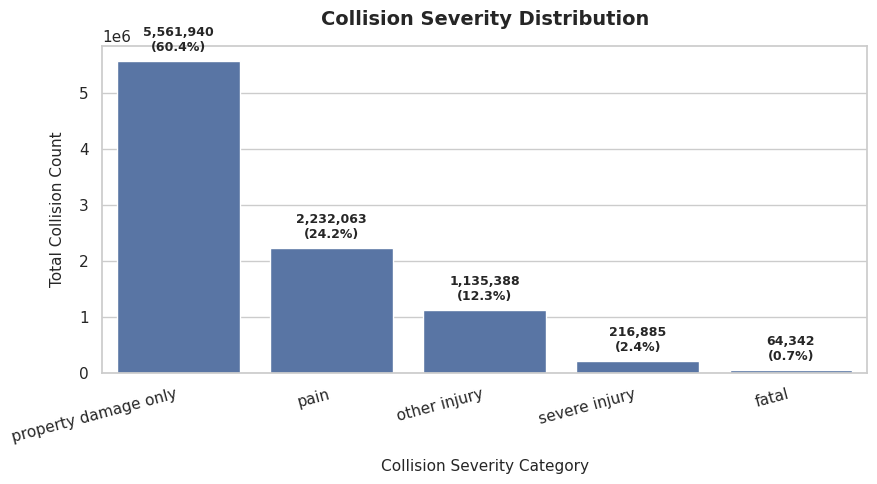

,severity,count,percentage
0,property damage only,5561940,60.386176
1,pain,2232063,24.233586
2,other injury,1135388,12.326947
3,severe injury,216885,2.354728
4,fatal,64342,0.698563


In [4]:
# Univariate Analysis
# Collision Severity Distribution

import matplotlib.pyplot as plt
import seaborn as sns

severity_counts = (
    df_final.groupBy("severity")
    .agg(count("*").alias("count"))
    .orderBy(col("count").desc())
)
# Convert to Pandas
df_severity_pd = severity_counts.toPandas()

# Calculate percentages for clearer visual reporting
total_records = df_severity_pd["count"].sum()
df_severity_pd["percentage"] = (df_severity_pd["count"] / total_records) * 100

# Plot
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_severity_pd,
    x="severity",
    y="count",
    order=df_severity_pd["severity"]
)

# Add count and percentage labels above each bar
for p in ax.patches:
    height = p.get_height()
    pct = (height / total_records) * 100
    ax.annotate(
        f"{int(height):,}\n({pct:.1f}%)",
        xy=(p.get_x() + p.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Collision Severity Distribution", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Collision Severity Category", fontsize=11, labelpad=10)
plt.ylabel("Total Collision Count", fontsize=11, labelpad=10)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

# Display the underlying summary table
display(df_severity_pd)

##**3.1.3. Weather conditions during collisions.** <font color = red>[5 marks]</font> <br>

Q: Examine weather conditions during collisions.

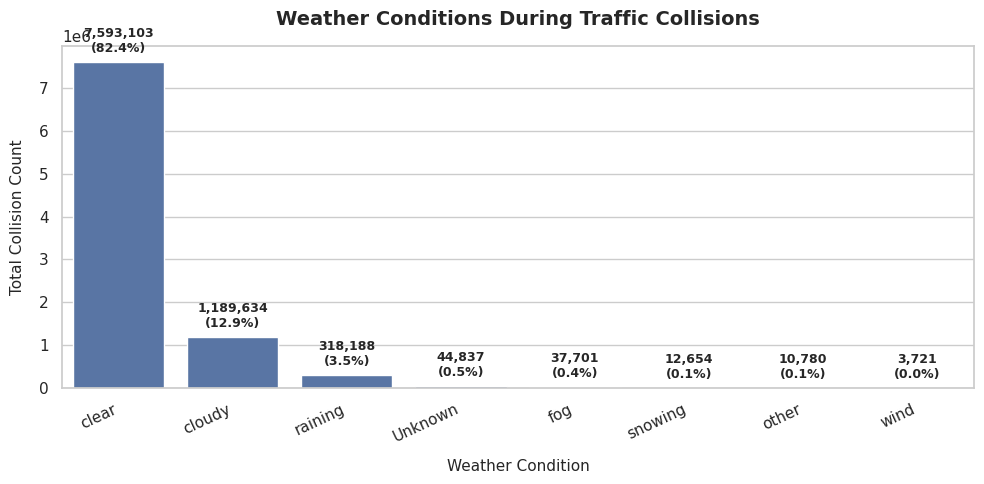

,weather_condition,count,percentage
0,clear,7593103,82.438583
1,cloudy,1189634,12.915898
2,raining,318188,3.454578
3,Unknown,44837,0.486797
4,fog,37701,0.409321
5,snowing,12654,0.137385
6,other,10780,0.117039
7,wind,3721,0.040399


In [5]:
# Weather Conditions During Collisions
weather_counts = (
    df_final.groupBy("weather_condition")
    .agg(count("*").alias("count"))
    .orderBy(col("count").desc())
)

# Convert to Pandas
df_weather_pd = weather_counts.toPandas()
total_records = df_weather_pd["count"].sum()
df_weather_pd["percentage"] = (df_weather_pd["count"] / total_records) * 100

# Plot
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_weather_pd,
    x="weather_condition",
    y="count",
    order=df_weather_pd["weather_condition"]
)

# Add count and percentage labels above each bar
for p in ax.patches:
    height = p.get_height()
    pct = (height / total_records) * 100
    ax.annotate(
        f"{int(height):,}\n({pct:.1f}%)",
        xy=(p.get_x() + p.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Weather Conditions During Traffic Collisions", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Weather Condition", fontsize=11, labelpad=10)
plt.ylabel("Total Collision Count", fontsize=11, labelpad=10)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

# Display the underlying summary table
display(df_weather_pd)

##**3.1.4. Victime Age Distribution.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of victim ages.

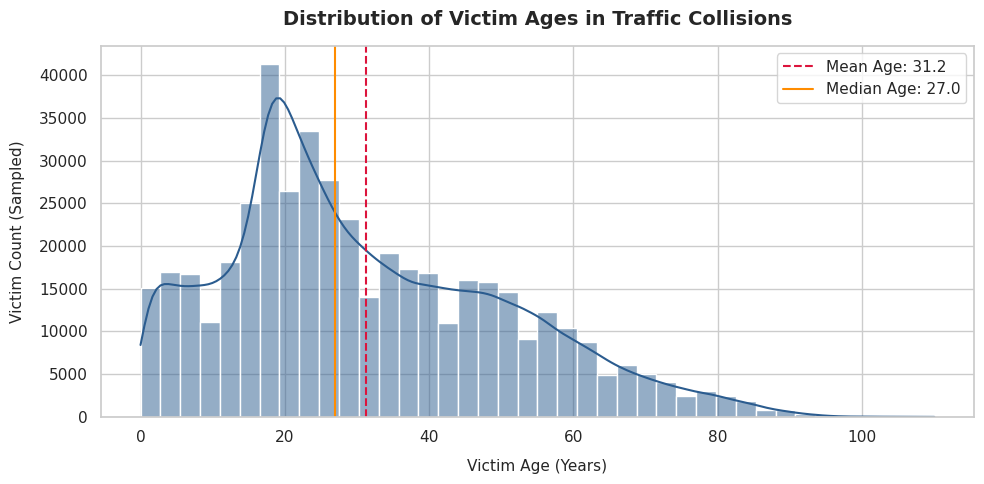

,count,unique,top,freq
victim_age,452379,110,18.000000000000000000,14661


In [6]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col
# Distribution of Victim Ages
sqlite_db_abs_path = os.path.abspath("ETL Project 1/dataset/switrs.sqlite")
jdbc_url = f"jdbc:sqlite:{sqlite_db_abs_path}"

# 2. Source-level column pruning & filtering via JDBC pushdown
victims_query = """
(
    SELECT 
        CAST(case_id AS INTEGER) AS case_id,
        CAST(victim_age AS INTEGER) AS victim_age
    FROM victims
    WHERE victim_age IS NOT NULL 
      AND victim_age >= 0 
      AND victim_age <= 110
) AS victims_subq
"""

df_victims = spark.read \
    .format("jdbc") \
    .option("url", jdbc_url) \
    .option("driver", "org.sqlite.JDBC") \
    .option("dbtable", victims_query) \
    .load() \
    .withColumn("case_id", col("case_id").cast("long"))

# 3. Distributed Join in Spark (inner join matches only valid collision cases)
df_victim_ages = df_final.select("case_id").join(
    df_victims,
    on="case_id",
    how="inner"
)

# 4. Safe downsample to avoid driver OOM crashes
df_victim_ages_pd = df_victim_ages.select("victim_age") \
    .sample(withReplacement=False, fraction=0.05, seed=42) \
    .toPandas()

# 5. Plot Victim Age Distribution
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")
sns.histplot(
    df_victim_ages_pd["victim_age"], 
    bins=40, 
    kde=True, 
    color="#2b5c8f", 
    edgecolor="white"
)

mean_age = df_victim_ages_pd["victim_age"].mean()
median_age = df_victim_ages_pd["victim_age"].median()

plt.axvline(mean_age, color="crimson", linestyle="--", linewidth=1.5, label=f"Mean Age: {mean_age:.1f}")
plt.axvline(median_age, color="darkorange", linestyle="-", linewidth=1.5, label=f"Median Age: {median_age:.1f}")

plt.title("Distribution of Victim Ages in Traffic Collisions", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Victim Age (Years)", fontsize=11, labelpad=10)
plt.ylabel("Victim Count (Sampled)", fontsize=11, labelpad=10)
plt.legend(frameon=True, facecolor="white", loc="upper right")
plt.tight_layout()
plt.show()

# 6. Summary metrics
display(df_victim_ages_pd.describe().T)

##**3.1.5. Collision Severity vs Number of Victims.** <font color = red>[5 marks]</font> <br>

Q: Study the relationship between collision severity and the number of victims.

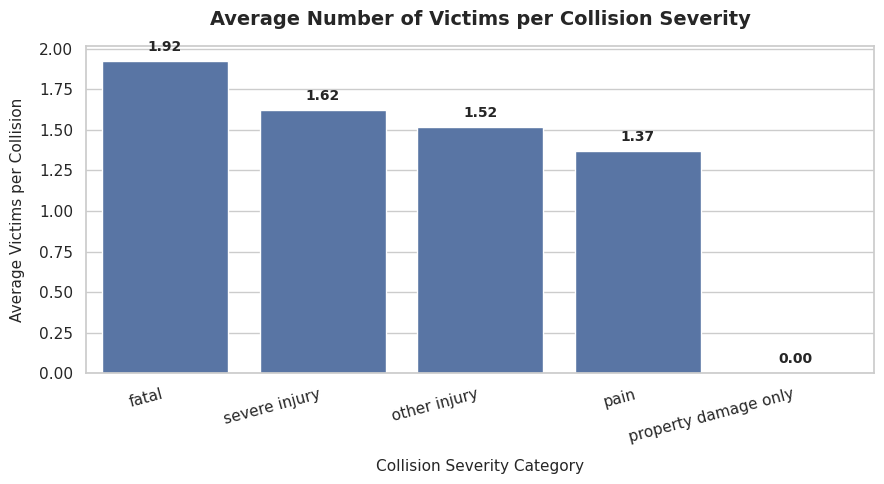

,severity,total_collisions,avg_victims_per_collision,avg_injured_victims,avg_killed_victims,total_victims_count
0,fatal,64342,1.922228,0.824516,1.097712,123680
1,severe injury,216885,1.622348,1.622348,0.000000,351863
2,other injury,1135388,1.516663,1.516663,0.000000,1722001
3,pain,2232063,1.368892,1.368892,0.000000,3055453
4,property damage only,5561940,0.000000,0.000000,0.000000,0


In [7]:
# Bivariate Analysis

# Collision Severity vs. Number of Victims
severity_victim_summary = (
    df_final.withColumn("total_victims", col("killed_victims") + col("injured_victims"))
    .groupBy("severity")
    .agg(
        count("*").alias("total_collisions"),
        avg("total_victims").alias("avg_victims_per_collision"),
        avg("injured_victims").alias("avg_injured_victims"),
        avg("killed_victims").alias("avg_killed_victims"),
        sum("total_victims").alias("total_victims_count")
    )
    .orderBy(col("avg_victims_per_collision").desc())
)
# Convert to Pandas
df_severity_victims_pd = severity_victim_summary.toPandas()
# Plot
plt.figure(figsize=(9, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_severity_victims_pd,
    x="severity",
    y="avg_victims_per_collision",
    order=df_severity_victims_pd["severity"]
)

# Add exact average labels above each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.2f}",
        xy=(p.get_x() + p.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Average Number of Victims per Collision Severity", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Collision Severity Category", fontsize=11, labelpad=10)
plt.ylabel("Average Victims per Collision", fontsize=11, labelpad=10)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

# Display summary statistics
display(df_severity_victims_pd)

##**3.1.6. Weather Conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the correlation between weather conditions and collision severity.

<Figure size 1100x600 with 0 Axes>

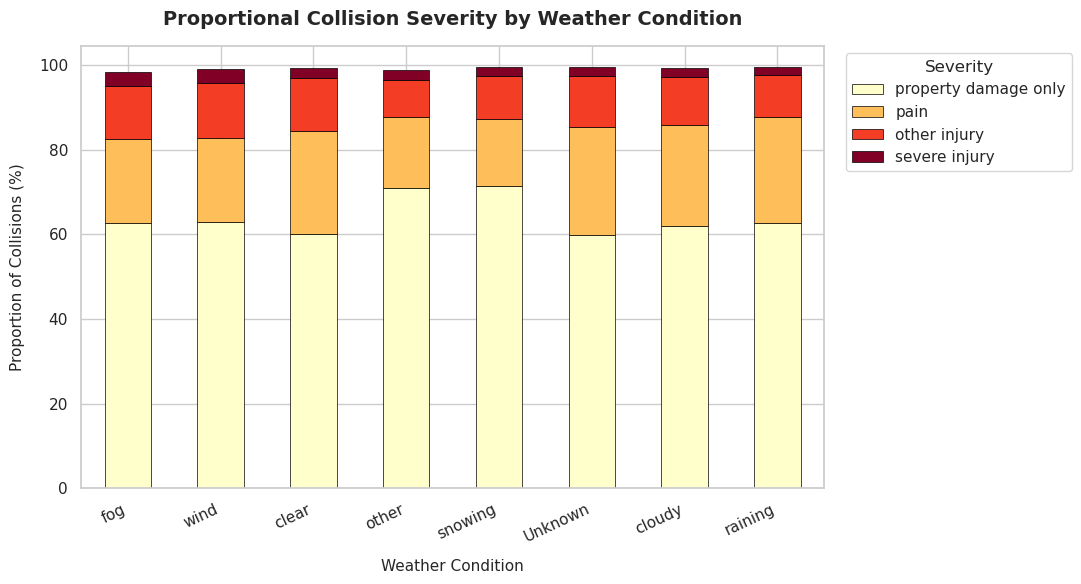

severity,property damage only,pain,other injury,severe injury
weather_condition,,,,
fog,62.70,19.71,12.73,3.32
wind,62.89,19.94,12.98,3.17
clear,59.99,24.32,12.58,2.41
other,71.00,16.60,8.82,2.38
snowing,71.46,15.88,10.05,2.16
Unknown,59.85,25.44,12.08,2.13
cloudy,61.98,23.77,11.42,2.09
raining,62.79,24.87,9.99,1.85


In [8]:
# Weather vs. Collision Severity
weather_severity_counts = (
    df_final.groupBy("weather_condition", "severity")
    .agg(count("*").alias("collision_count"))
)
# Convert to Pandas
df_ws_pd = weather_severity_counts.toPandas()
pivot_counts = df_ws_pd.pivot(
    index="weather_condition", 
    columns="severity", 
    values="collision_count"
).fillna(0)

# Filter to weather conditions with significant incident volume (> 100 crashes)
# to avoid skewing normalized distributions with micro-categories
valid_weather = pivot_counts.sum(axis=1) > 100
pivot_counts = pivot_counts[valid_weather]

# 3. Calculate percentage breakdown per weather condition (row-normalized %)
pivot_pct = pivot_counts.div(pivot_counts.sum(axis=1), axis=0) * 100

# Order severity columns logically by increasing risk
severity_order = ["property damage only", "pain", "other injury", "severe injury"]
existing_cols = [c for c in severity_order if c in pivot_pct.columns]
pivot_pct = pivot_pct[existing_cols].sort_values(by="severe injury", ascending=False)

# Plot
plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")

ax = pivot_pct.plot(
    kind="bar", 
    stacked=True, 
    figsize=(11, 6), 
    colormap="YlOrRd", 
    edgecolor="black",
    linewidth=0.5
)

plt.title("Proportional Collision Severity by Weather Condition", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Weather Condition", fontsize=11, labelpad=10)
plt.ylabel("Proportion of Collisions (%)", fontsize=11, labelpad=10)
plt.xticks(rotation=25, ha="right")
plt.legend(title="Severity", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.tight_layout()
plt.show()
# Display contingency breakdown percentage table
display(pivot_pct.round(2))

##**3.1.7. Lighting conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q:Visualize the impact of lighting conditions on collision severity.

<Figure size 1100x600 with 0 Axes>

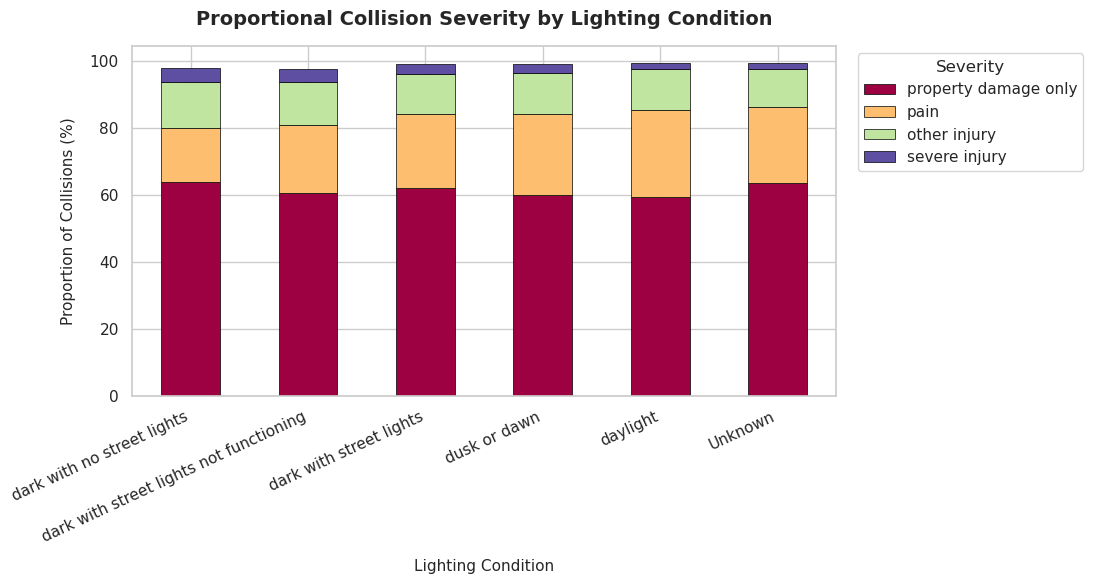

severity,property damage only,pain,other injury,severe injury
lighting_condition,,,,
dark with no street lights,64.02,16.03,13.68,4.25
dark with street lights not functioning,60.71,20.20,12.71,3.97
dark with street lights,62.20,21.92,12.02,2.93
dusk or dawn,59.98,24.04,12.37,2.71
daylight,59.37,25.98,12.27,1.93
Unknown,63.52,22.84,11.26,1.89


In [9]:
# Lighting Conditions vs. Collision Severity
lighting_severity_counts = (
    df_final.groupBy("lighting_condition", "severity")
    .agg(count("*").alias("collision_count"))
)
# Convert to Pandas
df_ls_pd = lighting_severity_counts.toPandas()

# 2. Pivot into a contingency matrix
pivot_lighting = df_ls_pd.pivot(
    index="lighting_condition", 
    columns="severity", 
    values="collision_count"
).fillna(0)

# Filter low-volume categories (< 100 occurrences) to maintain clean proportions
valid_lighting = pivot_lighting.sum(axis=1) > 100
pivot_lighting = pivot_lighting[valid_lighting]

# 3. Calculate row-normalized percentages
pivot_lighting_pct = pivot_lighting.div(pivot_lighting.sum(axis=1), axis=0) * 100

# Order severity levels by risk progression
severity_order = ["property damage only", "pain", "other injury", "severe injury"]
existing_cols = [c for c in severity_order if c in pivot_lighting_pct.columns]
pivot_lighting_pct = pivot_lighting_pct[existing_cols].sort_values(by="severe injury", ascending=False)
# Plot
plt.figure(figsize=(11, 6))
sns.set_theme(style="whitegrid")

ax = pivot_lighting_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6),
    colormap="Spectral",
    edgecolor="black",
    linewidth=0.5
)

plt.title("Proportional Collision Severity by Lighting Condition", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Lighting Condition", fontsize=11, labelpad=10)
plt.ylabel("Proportion of Collisions (%)", fontsize=11, labelpad=10)
plt.xticks(rotation=25, ha="right")
plt.legend(title="Severity", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

# Display summary table of percentages
display(pivot_lighting_pct.round(2))

##**3.1.8. Weekday-Wise Collision Trends.** <font color = red>[7 marks]</font> <br>

Q: Extract and analyze weekday-wise collision trends.

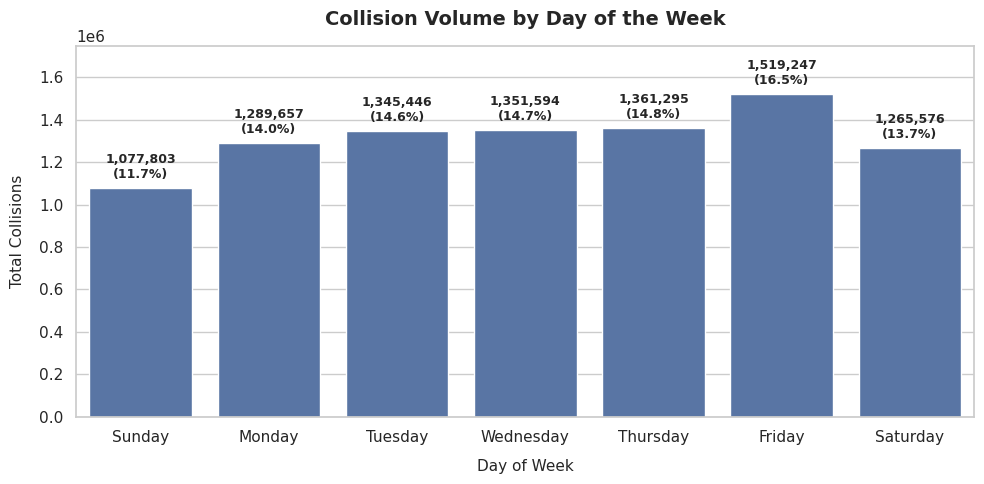

,day_num,weekday,collision_count,percentage
0,1,Sunday,1077803,11.701745
1,2,Monday,1289657,14.001851
2,3,Tuesday,1345446,14.607554
3,4,Wednesday,1351594,14.674303
4,5,Thursday,1361295,14.779627
5,6,Friday,1519247,16.494518
6,7,Saturday,1265576,13.740403


In [10]:
from pyspark.sql.functions import date_format,dayofweek
# Extract the weekday
weekday_summary = (
    df_final.withColumn("day_num", dayofweek(col("collision_date")))
    .withColumn("weekday", date_format(col("collision_date"), "EEEE"))
    .groupBy("day_num", "weekday")
    .agg(count("*").alias("collision_count"))
    .orderBy("day_num")
)

# Convert only the 7 aggregated rows to Pandas
df_weekday_pd = weekday_summary.toPandas()

# Calculate proportions
total_collisions = df_weekday_pd["collision_count"].sum()
df_weekday_pd["percentage"] = (df_weekday_pd["collision_count"] / total_collisions) * 100
# Plot
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_weekday_pd,
    x="weekday",
    y="collision_count"
)

# Annotate counts and percentages over each bar
for p in ax.patches:
    height = p.get_height()
    pct = (height / total_collisions) * 100
    ax.annotate(
        f"{int(height):,}\n({pct:.1f}%)",
        xy=(p.get_x() + p.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Collision Volume by Day of the Week", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Day of Week", fontsize=11, labelpad=10)
plt.ylabel("Total Collisions", fontsize=11, labelpad=10)
plt.ylim(0, df_weekday_pd["collision_count"].max() * 1.15)
plt.tight_layout()
plt.show()

# Display summary table
display(df_weekday_pd[["day_num", "weekday", "collision_count", "percentage"]])

##**3.1.9. Spatial Distribution of Collisions.** <font color = red>[7 marks]</font> <br>

Q: Study spatial distribution of collisions by county.

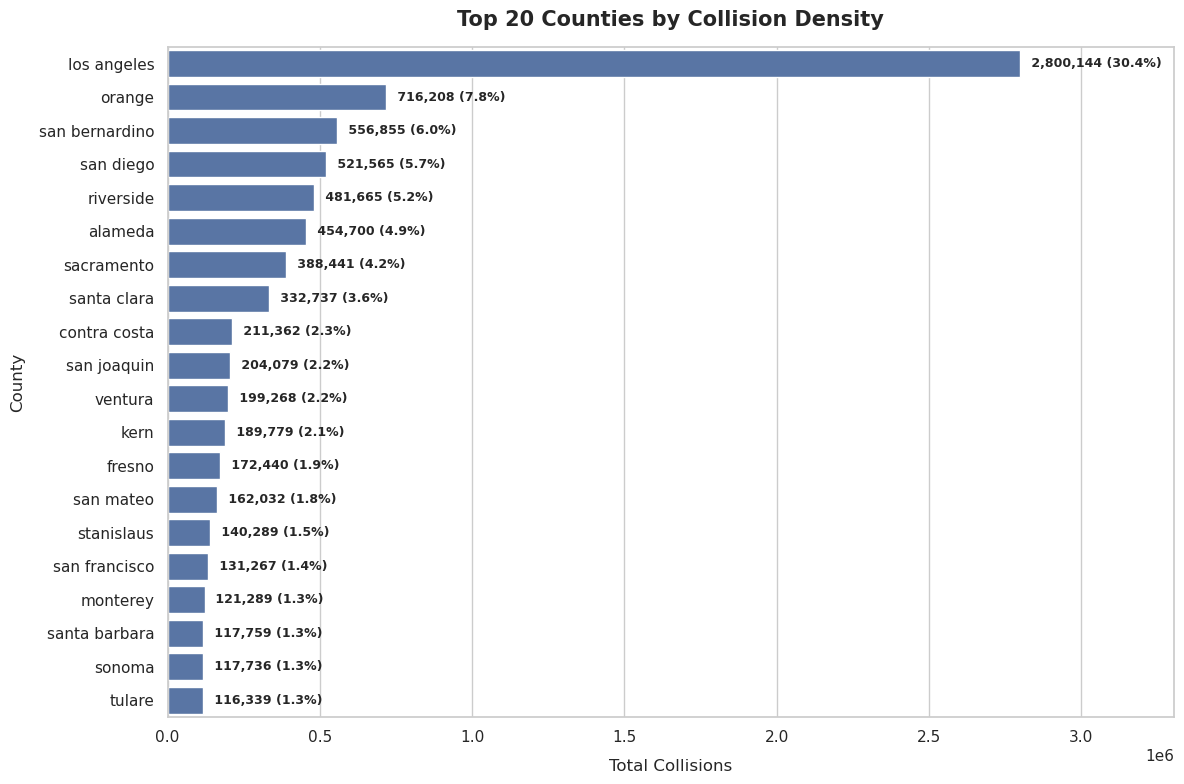

,county_location,collision_count,percentage
0,los angeles,2800144,30.401261
1,orange,716208,7.775895
2,san bernardino,556855,6.045794
3,san diego,521565,5.662649
4,riverside,481665,5.229454
5,alameda,454700,4.936694
6,sacramento,388441,4.217317
7,santa clara,332737,3.612537
8,contra costa,211362,2.294765
9,san joaquin,204079,2.215693


In [11]:
# Spatial Analysis

# Collision Density by County
county_density = (
    df_final.filter(
        col("county_location").isNotNull() & 
        (col("county_location") != "Unknown")
    )
    .groupBy("county_location")
    .agg(count("*").alias("collision_count"))
    .orderBy(col("collision_count").desc())
)

# Convert aggregated summary to Pandas
df_county_pd = county_density.toPandas()

# Calculate county percentage share
total_county_collisions = df_county_pd["collision_count"].sum()
df_county_pd["percentage"] = (df_county_pd["collision_count"] / total_county_collisions) * 100
# Plot the map
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

top_20_counties = df_county_pd.head(20)

ax = sns.barplot(
    data=top_20_counties,
    x="collision_count",
    y="county_location"
)

# Annotate each bar with raw count and percentage
for p in ax.patches:
    width = p.get_width()
    pct = (width / total_county_collisions) * 100
    ax.annotate(
        f" {int(width):,} ({pct:.1f}%)",
        xy=(width, p.get_y() + p.get_height() / 2),
        xytext=(5, 0),
        textcoords="offset points",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Top 20 Counties by Collision Density", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Total Collisions", fontsize=12, labelpad=10)
plt.ylabel("County", fontsize=12, labelpad=10)
plt.xlim(0, top_20_counties["collision_count"].max() * 1.18)
plt.tight_layout()
plt.show()

# Display the top 10 counties
display(top_20_counties[["county_location", "collision_count", "percentage"]].head(10))

##**3.1.10. Collision Analysis by Geography.** <font color = red>[6 marks]</font> <br>

Q: Generate a scatter plot to analyze collision locations geographically.

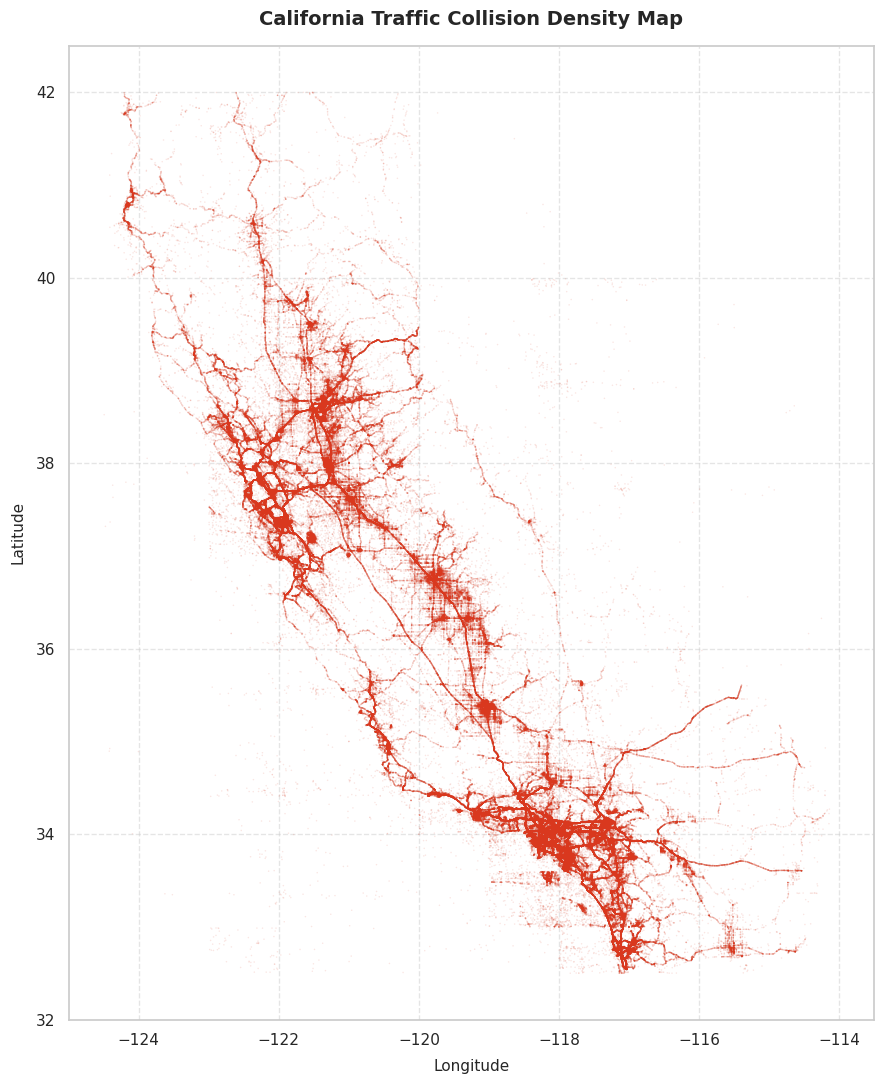

Total points plotted: 674,591


In [12]:
# Scatter Plot of Collision Locations
df_geo_spark = (
    df_final.filter(
        col("latitude").isNotNull()
        & col("longitude").isNotNull()
        & (col("latitude") >= 32.5)
        & (col("latitude") <= 42.0)
        & (col("longitude") >= -124.5)
        & (col("longitude") <= -114.0)
    )
    .select("latitude", "longitude", "severity")
    .sample(withReplacement=False, fraction=0.25, seed=42)
)
# Convert PySpark DataFrame to Pandas, handling potential missing values
df_geo_pd = df_geo_spark.toPandas().dropna(subset=["latitude", "longitude"])
# Convert to numeric (if needed) and handle invalid data
df_geo_pd["latitude"] = pd.to_numeric(df_geo_pd["latitude"], errors="coerce")
df_geo_pd["longitude"] = pd.to_numeric(df_geo_pd["longitude"], errors="coerce")
df_geo_pd = df_geo_pd.dropna(subset=["latitude", "longitude"])
# Plot the scatter plot
plt.figure(figsize=(9, 11))

plt.scatter(
    df_geo_pd["longitude"],
    df_geo_pd["latitude"],
    c="#d9381e",
    alpha=0.12,
    s=1.2,
    edgecolors="none",
    rasterized=True
)

plt.title("California Traffic Collision Density Map", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Longitude", fontsize=11, labelpad=8)
plt.ylabel("Latitude", fontsize=11, labelpad=8)
plt.xlim(-125.0, -113.5)
plt.ylim(32.0, 42.5)
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print(f"Total points plotted: {len(df_geo_pd):,}")

##**3.1.11. Collision Trends Over Time.** <font color = red>[10 marks]</font> <br>

Extract and analyzing collision trends over time.

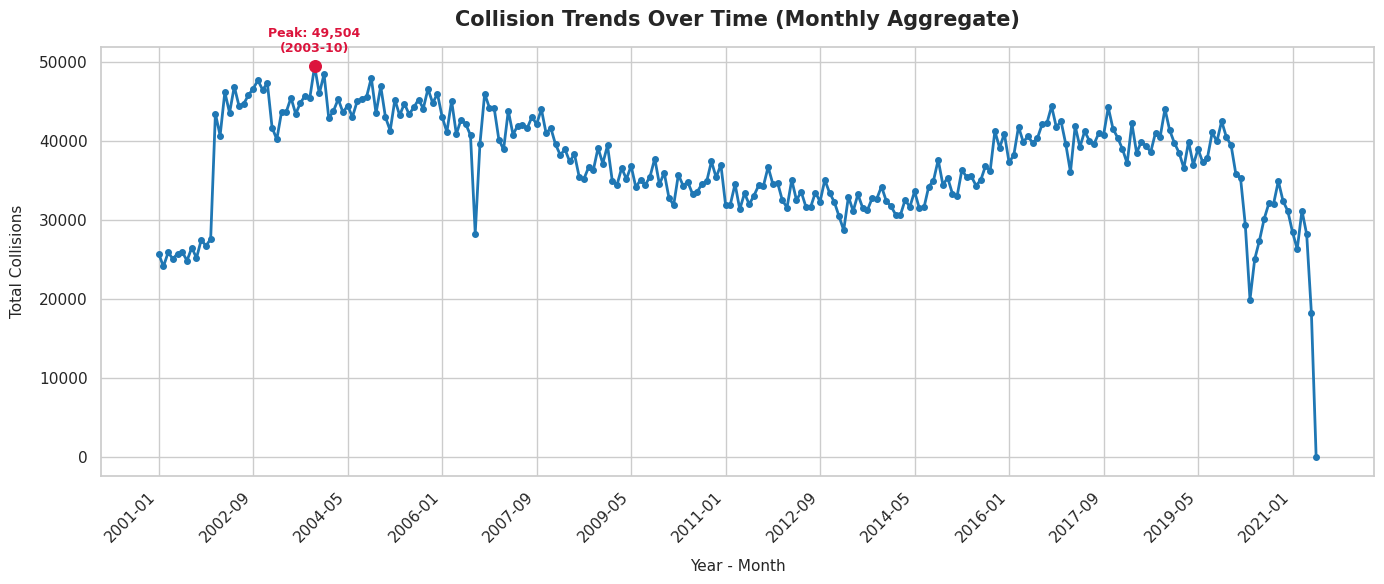

,year_month,year,month,collision_count
0,2001-01,2001,1,25780
1,2001-02,2001,2,24163
2,2001-03,2001,3,25938
3,2001-04,2001,4,25129
4,2001-05,2001,5,25807
5,2001-06,2001,6,25966
6,2001-07,2001,7,24905
7,2001-08,2001,8,26550
8,2001-09,2001,9,25241
9,2001-10,2001,10,27526


In [13]:
from pyspark.sql.functions import year, month, hour, to_timestamp, col,date_format
import matplotlib.pyplot as plt
import seaborn as sns
# Extract year and month from collision_date
monthly_trends = (
    df_final.filter(col("collision_date").isNotNull())
    .withColumn("year", year(col("collision_date")))
    .withColumn("month", month(col("collision_date")))
    .withColumn("year_month", date_format(col("collision_date"), "yyyy-MM"))
    .groupBy("year_month", "year", "month")
    .agg(count("*").alias("collision_count"))
    .orderBy("year_month")
)

# Convert aggregated monthly series to Pandas (only transfers small summary data)
df_trends_pd = monthly_trends.toPandas()
# Plot
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

plt.plot(
    df_trends_pd["year_month"],
    df_trends_pd["collision_count"],
    marker="o",
    markersize=4,
    color="#1f77b4",
    linewidth=2,
    label="Monthly Collisions"
)

# Annotate peaks and troughs
max_row = df_trends_pd.loc[df_trends_pd["collision_count"].idxmax()]
min_row = df_trends_pd.loc[df_trends_pd["collision_count"].idxmin()]

plt.scatter([max_row["year_month"]], [max_row["collision_count"]], color="crimson", s=70, zorder=5)
plt.annotate(
    f"Peak: {int(max_row['collision_count']):,}\n({max_row['year_month']})",
    xy=(max_row["year_month"], max_row["collision_count"]),
    xytext=(0, 10),
    textcoords="offset points",
    ha="center",
    fontsize=9,
    fontweight="bold",
    color="crimson"
)

plt.title("Collision Trends Over Time (Monthly Aggregate)", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Year - Month", fontsize=11, labelpad=10)
plt.ylabel("Total Collisions", fontsize=11, labelpad=10)

# Display every 3rd or 6th tick label to keep the x-axis readable
step = max(1, len(df_trends_pd) // 12)
plt.xticks(
    ticks=range(0, len(df_trends_pd), step),
    labels=df_trends_pd["year_month"].iloc[::step],
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

# Display summary table of monthly trends
display(df_trends_pd.head(12))

Q: Analyze yearly, monthly and hourly trends in collisions.

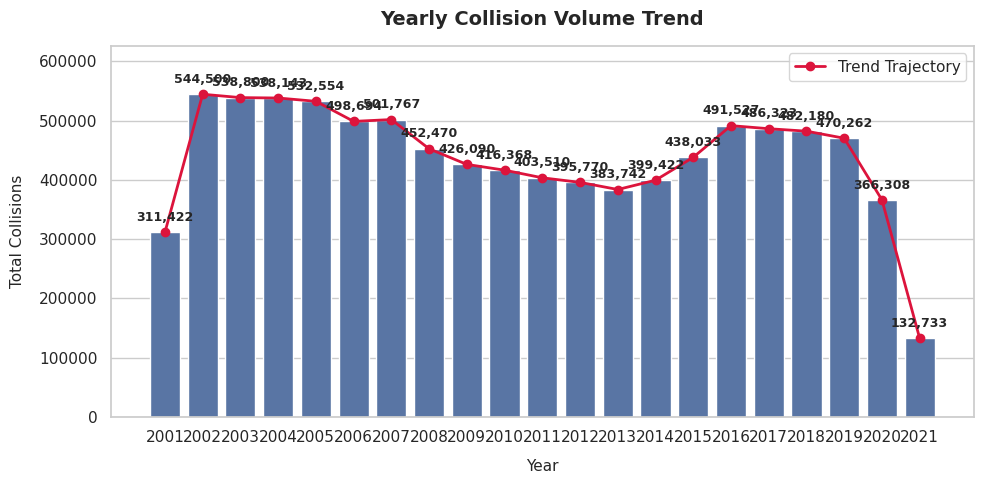

,collision_year,collision_count
0,2001,311422
1,2002,544500
2,2003,538800
3,2004,538143
4,2005,532554
5,2006,498694
6,2007,501767
7,2008,452470
8,2009,426090
9,2010,416368


In [14]:
# Yearly Trend of Collisions
yearly_trends = (
    df_final.filter(col("collision_date").isNotNull())
    .withColumn("collision_year", year(col("collision_date")))
    .groupBy("collision_year")
    .agg(count("*").alias("collision_count"))
    .orderBy("collision_year")
)

# Convert to Pandas (only transfers a handful of summary rows)
df_yearly_pd = yearly_trends.toPandas()
# Plot
plt.figure(figsize=(10, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_yearly_pd,
    x="collision_year",
    y="collision_count"
)

# Add line overlay to visualize the trajectory clearly
plt.plot(
    range(len(df_yearly_pd)),
    df_yearly_pd["collision_count"],
    color="crimson",
    marker="o",
    linewidth=2,
    label="Trend Trajectory"
)

# Annotate each bar with exact incident count
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{int(height):,}",
        xy=(p.get_x() + p.get_width() / 2, height),
        xytext=(0, 6),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold"
    )

plt.title("Yearly Collision Volume Trend", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Year", fontsize=11, labelpad=10)
plt.ylabel("Total Collisions", fontsize=11, labelpad=10)
plt.ylim(0, df_yearly_pd["collision_count"].max() * 1.15)
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()

# Display summary table
display(df_yearly_pd)


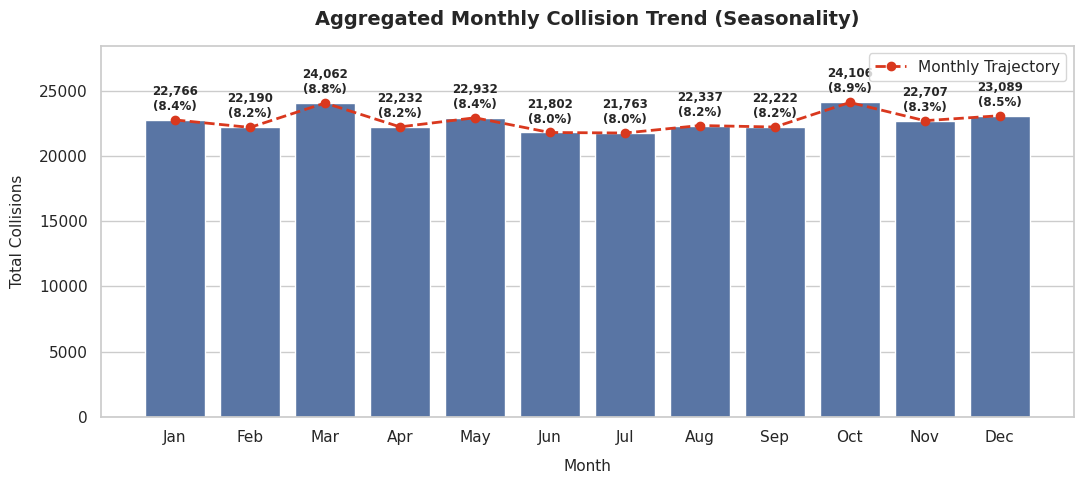

In [15]:
# Monthly Trend of Collisions
monthly_seasonality = (
    df_final.filter(col("collision_date").isNotNull())
    .withColumn("month_num", month(col("collision_date")))
    .withColumn("month_name", date_format(col("collision_date"), "MMM"))
    .groupBy("month_num", "month_name")
    .agg(count("*").alias("collision_count"))
    .orderBy("month_num")
)

# Convert only the 12 aggregated summary rows to Pandas
df_monthly_pd = monthly_seasonality.toPandas()

# Calculate relative proportions
total_records = df_monthly_pd["collision_count"].sum()
df_monthly_pd["percentage"] = (df_monthly_pd["collision_count"] / total_records) * 100
# Plot
plt.figure(figsize=(11, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_monthly_pd,
    x="month_name",
    y="collision_count"
)

# Overlay trend trajectory
plt.plot(
    range(len(df_monthly_pd)),
    df_monthly_pd["collision_count"],
    color="#d9381e",
    marker="o",
    linewidth=2,
    linestyle="--",
    label="Monthly Trajectory"
)

# Annotate counts and percentages over each bar
for p in ax.patches:
    height = p.get_height()
    pct = (height / total_records) * 100
    ax.annotate(
        f"{int(height):,}\n({pct:.1f}%)",
        xy=(p.get_x() + p.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=8.5,
        fontweight="bold"
    )

plt.title("Aggregated Monthly Collision Trend (Seasonality)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Month", fontsize=11, labelpad=10)
plt.ylabel("Total Collisions", fontsize=11, labelpad=10)
plt.ylim(0, df_monthly_pd["collision_count"].max() * 1.18)
plt.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()


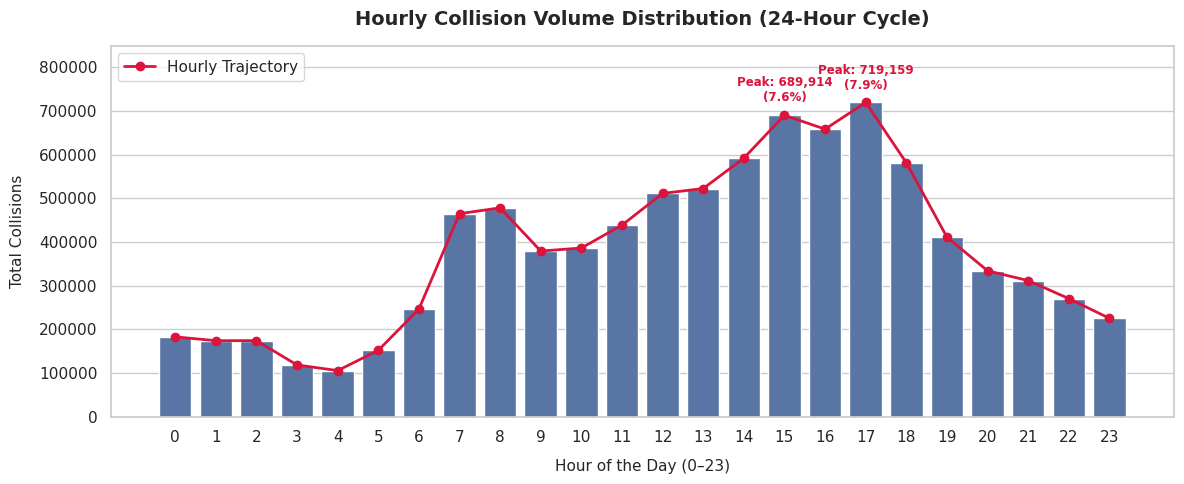

In [15]:
# Hourly Trend of Collisions
hourly_trends = (
    df_final.filter(
        col("collision_hour").isNotNull()
        & (col("collision_hour") >= 0)
        & (col("collision_hour") <= 23)
    )
    .groupBy("collision_hour")
    .agg(count("*").alias("collision_count"))
    .orderBy("collision_hour")
)

# Convert only 24 aggregated rows to Pandas
df_hourly_pd = hourly_trends.toPandas()

# Calculate proportions
total_records = df_hourly_pd["collision_count"].sum()
df_hourly_pd["percentage"] = (df_hourly_pd["collision_count"] / total_records) * 100
# Plot
plt.figure(figsize=(12, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_hourly_pd,
    x="collision_hour",
    y="collision_count"
)

# Overlay trend trajectory line
plt.plot(
    range(len(df_hourly_pd)),
    df_hourly_pd["collision_count"],
    color="crimson",
    marker="o",
    linewidth=2,
    label="Hourly Trajectory"
)

# Highlight morning and evening peak hours
peak_hours = df_hourly_pd.nlargest(2, "collision_count")
for _, row in peak_hours.iterrows():
    h = int(row["collision_hour"])
    cnt = int(row["collision_count"])
    pct = row["percentage"]
    plt.annotate(
        f"Peak: {cnt:,}\n({pct:.1f}%)",
        xy=(h, cnt),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        fontsize=8.5,
        fontweight="bold",
        color="crimson"
    )

plt.title("Hourly Collision Volume Distribution (24-Hour Cycle)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Hour of the Day (0–23)", fontsize=11, labelpad=10)
plt.ylabel("Total Collisions", fontsize=11, labelpad=10)
plt.xticks(range(24))
plt.ylim(0, df_hourly_pd["collision_count"].max() * 1.18)
plt.legend(loc="upper left", frameon=True)
plt.tight_layout()
plt.show()

#**4. ETL Querying** <font color = red>[35 marks]</font> <br>

## **4.1. Top 5 Counties** <font color = red>[4 marks]</font> <br>

Q: Identify the top 5 counties with the highest number of collisions.

In [47]:
# Query: Identify the top 5 counties with the most collisions
df_final.createOrReplaceTempView("collisions")

# PySpark SQL Query to find the top 5 counties with the most collisions
top_5_counties = spark.sql("""
    SELECT 
        county_location,
        COUNT(*) AS collision_count
    FROM collisions
    WHERE county_location IS NOT NULL 
      AND county_location != 'Unknown'
    GROUP BY county_location
    ORDER BY collision_count DESC
    LIMIT 5
""")

top_5_counties.show(truncate=False)

+---------------+---------------+
|county_location|collision_count|
+---------------+---------------+
|los angeles    |2800144        |
|orange         |716208         |
|san bernardino |556855         |
|san diego      |521565         |
|riverside      |481665         |
+---------------+---------------+



## **4.2. Month with Highest Collisions** <font color = red>[5 marks]</font> <br>

Q. Identify the month with the highest number of collisions.

In [48]:
# Query: Find the month with the highest number of collisions
spark.sql("""
    SELECT 
        MONTH(collision_date) AS month_num,
        DATE_FORMAT(collision_date, 'MMMM') AS month_name,
        COUNT(*) AS collision_count
    FROM collisions
    WHERE collision_date IS NOT NULL
    GROUP BY MONTH(collision_date), DATE_FORMAT(collision_date, 'MMMM')
    ORDER BY collision_count DESC
    LIMIT 1
""").show(truncate=False)

+---------+----------+---------------+
|month_num|month_name|collision_count|
+---------+----------+---------------+
|10       |October   |819610         |
+---------+----------+---------------+



## **4.3. Weather Conditions with Highest Collisions.** <font color = red>[5 marks]</font> <br>

Q. Determine the most common weather condition during collisions.

In [49]:
# Query: Find the most common weather condition during collisions

most_common_weather = spark.sql("""
    SELECT 
        weather_condition,
        COUNT(*) AS collision_count
    FROM collisions
    WHERE weather_condition IS NOT NULL 
      AND weather_condition != 'Unknown'
    GROUP BY weather_condition
    ORDER BY collision_count DESC
    LIMIT 1
""")

most_common_weather.show(truncate=False)

+-----------------+---------------+
|weather_condition|collision_count|
+-----------------+---------------+
|clear            |7593103        |
+-----------------+---------------+



## **4.4. Fatal Collisions.** <font color = red>[5 marks]</font> <br>

Q. Calculate the percentage of collisions that resulted in fatalities.

In [50]:
# Query: Determine the percentage of collisions that resulted in fatalities
fatal_percentage_df = spark.sql("""
    SELECT 
        COUNT(*) AS total_collisions,
        SUM(CASE WHEN killed_victims > 0 OR LOWER(severity) = 'fatal' THEN 1 ELSE 0 END) AS fatal_collisions,
        ROUND(
            (SUM(CASE WHEN killed_victims > 0 OR LOWER(severity) = 'fatal' THEN 1 ELSE 0 END) * 100.0) / COUNT(*), 
            2
        ) AS fatal_percentage
    FROM collisions
""")

fatal_percentage_df.show(truncate=False)

+----------------+----------------+----------------+
|total_collisions|fatal_collisions|fatal_percentage|
+----------------+----------------+----------------+
|9210618         |64342           |0.70            |
+----------------+----------------+----------------+



## **4.5. Dangerous Time for Collisions.** <font color = red>[5 marks]</font> <br>

Q. Find the most dangerous time of day for collisions.

In [51]:
# Query: Find the most dangerous time of day for collisions
dangerous_time_df = spark.sql("""
    SELECT 
        collision_hour,
        COUNT(*) AS collision_count
    FROM collisions
    WHERE collision_hour IS NOT NULL 
      AND collision_hour BETWEEN 0 AND 23
    GROUP BY collision_hour
    ORDER BY collision_count DESC
    LIMIT 1
""")

dangerous_time_df.show(truncate=False)

+--------------+---------------+
|collision_hour|collision_count|
+--------------+---------------+
|17            |719159         |
+--------------+---------------+



## **4.6. Road Surface Conditions.** <font color = red>[5 marks]</font> <br>

Q. Identify the top 5 road surface conditions with the highest collision frequency.

In [52]:
# Query: List the top 5 road types with the highest collision frequency
top_5_road_surface = spark.sql("""
    SELECT 
        road_surface,
        COUNT(*) AS collision_count
    FROM collisions
    WHERE road_surface IS NOT NULL 
      AND road_surface != 'Unknown'
    GROUP BY road_surface
    ORDER BY collision_count DESC
    LIMIT 5
""")

top_5_road_surface.show(truncate=False)

+------------+---------------+
|road_surface|collision_count|
+------------+---------------+
|dry         |8328994        |
|wet         |750571         |
|snowy       |40133          |
|slippery    |10471          |
|H           |101            |
+------------+---------------+



## **4.7. Lighting Conditions.** <font color = red>[5 marks]</font> <br>

Q. Analyze lighting conditions that contribute to the highest number of collisions.

In [53]:
# Query: Find the top 3 lighting conditions that lead to the most collisions
top_3_lighting = spark.sql("""
    SELECT 
        lighting_condition,
        COUNT(*) AS collision_count
    FROM collisions
    WHERE lighting_condition IS NOT NULL 
      AND lighting_condition != 'Unknown'
    GROUP BY lighting_condition
    ORDER BY collision_count DESC
    LIMIT 3
""")

top_3_lighting.show(truncate=False)

+--------------------------+---------------+
|lighting_condition        |collision_count|
+--------------------------+---------------+
|daylight                  |6133074        |
|dark with street lights   |1954725        |
|dark with no street lights|729810         |
+--------------------------+---------------+



#5. Conclusion <font color = red>[10 marks]</font> <br>

Write your conclusion.

Working through this 9.2-million-row SWITRS dataset in PySpark highlighted clear differences between what causes sheer collision volume versus what drives incident severity. From an ETL and pipeline design perspective, cleaning the raw records, dropping sparse columns with over 60% nulls, and saving optimized Parquet files gave us a solid foundation to query the numbers accurately.

Core Findings from the Data

Exposure over Weather Extremes: Counterintuitively, over 82% of collisions occurred under clear skies, and more than 90% happened on dry roads. High accident totals are primarily a product of traffic density and congestion rather than adverse weather.

Commute Pressure Points: Collision volume tracks commuter flow, climbing steadily across the workweek to peak on Friday (16.5%). Daily traffic spikes sharply at 17:00 (5:00 PM), which logged over 719,000 crashes statewide.

Geographic Bottlenecks: Accidents cluster tightly in major urban hubs. Southern California carries most of the burden, with Los Angeles County alone accounting for over 30.4% (~2.8M) of all incidents, followed by Orange (7.8%) and San Bernardino (6.0%).

Infrastructure vs. Severity Risk: While absolute numbers are highest during daylight, collisions on roads marked "dark with no street lights" yielded more than double the proportion of severe injuries (~4.25%) compared to daylight (~1.93%). Poor visibility directly compounds crash severity.

Demographic Vulnerability: The age distribution peaks heavily around young motorists (ages 18 to 25), pointing to driver inexperience as a major recurring risk factor.

Practical Engineering and Policy Takeaways

Targeted Caltrans Investments: State funding should prioritize lighting installations and safety barrier retrofits in high-density corridors across Los Angeles, Orange, and San Bernardino counties, targeting unlit arterial roads first.

Dynamic Traffic Management: Transportation agencies can use the 16:00–19:00 weekday window to deploy adaptive signal timing and variable highway speed limits, dampening the shockwave braking that fuels high collision rates.

Vulnerable Road User Protection: City planning boards need to prioritize physical barriers and dedicated signal phases at dense urban intersections rather than standard painted lanes.

Next Steps for the Data Pipeline: With the cleaned tables partitioned and stored in Parquet/AWS S3, the logical progression is building an automated feature store. Joining live Caltrans sensor feeds with historical weather and crash density will let us train MLlib classification models to flag high-risk segments before the evening rush hour begins.

#6. Visualization Integration using Tableau/ PowerBI <font color = red>[Optional]</font> <br>